# EDA — Datos Radar FMCW Indoor

Análisis Exploratorio de los datos de medida en escenario indoor.
Todas las funciones de procesamiento y visualización residen en `src/eda_utils.py`.

**Estructura del tensor R** → shape `(N_t, N_f, 2, 2, 4)`

| Eje | Tamaño | Descripción |
|-----|--------|-------------|
| 0   | 549    | Capturas temporales |
| 1   | 1024   | Bins de frecuencia |
| 2   | 2      | TX_idx (0 o 1) |
| 3   | 2      | RX_idx (0 o 1) |
| 4   | 4      | Antena receptora física |


| (TX,RX) | Tipo |
|---------|------|
| (0,0) y (1,1) | **Monostático** |
| (0,1) y (1,0) | **Bistático** |

In [1]:
# ── Configuración de paths e imports ─────────────────────────────────────────
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
ROOT_DIR     = NOTEBOOK_DIR.parent
SRC_DIR      = ROOT_DIR / 'src'
DATA_PATH    = ROOT_DIR / 'data' / 'raw' / 'data.h5'
OUTPUT_DIR   = ROOT_DIR / 'data' / 'processed'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from eda_utils import (
    load_data, describe_dataset, get_config_labels,
    select_band, apply_window, compute_range_profile,
    plot_spectrum, plot_all_configs_spectrum,
    plot_range_profile, plot_all_configs_range_profile,
    plot_temporal_evolution, plot_antenna_matrix,
    compute_summary_stats, save_processed, save_processed_power_pdp,
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 100

print(f'Root     : {ROOT_DIR}')
print(f'Data     : {DATA_PATH}  |  existe: {DATA_PATH.exists()}')
print(f'Processed: {OUTPUT_DIR}')

Root     : C:\Users\carlos\Documents\cosas_carlos\TFG\mi_proyecto_ut
Data     : C:\Users\carlos\Documents\cosas_carlos\TFG\mi_proyecto_ut\data\raw\data.h5  |  existe: True
Processed: C:\Users\carlos\Documents\cosas_carlos\TFG\mi_proyecto_ut\data\processed


## 1. Carga y descripción del dataset

In [2]:
data = load_data(DATA_PATH)
describe_dataset(data)

  DESCRIPCIÓN DEL DATASET
  Archivo : data.h5

  ── Dimensiones del tensor R ──────────────────────────
    eje 0  ( 549)  → tiempo
    eje 1  (1024)  → frecuencia
    eje 2  (   2)  → TX_idx
    eje 3  (   2)  → RX_idx
    eje 4  (   4)  → rx_antenna

  ── Configuraciones TX/RX ─────────────────────────────
    (TX,RX)     Tipo            Label
    (0, 0)        Monostático   Mono TX0-RX0
    (1, 1)        Monostático   Mono TX1-RX1
    (0, 1)        Bistático     Bi   TX0-RX1
    (1, 0)        Bistático     Bi   TX1-RX0

  ── Frecuencias ───────────────────────────────────────
    Rango      : 77.0000 – 81.0000 GHz
    BW         : 4.0000 GHz
    Paso Δf    : 3.910 MHz
    Res. rango : 7.50 cm
    Max. rango : 76.73 m

  ── Timestamps ────────────────────────────────────────
    N capturas : 549
    Rango      : [1773245231677327360.0000, 1773245291759347712.0000]
    Duración   : 60082020352.0000 (u.t.)

  ── Estadísticas |R| ──────────────────────────────────
    dtype      : compl

## 2. Análisis Espectral

Espectro medio en dB para cada configuración TX/RX.  
Se superpone la versión con ventana de **Hamming** para ver el efecto del enventanado
(reduce el *spectral leakage* antes de la IFFT).  
La antena 0 se usa como referencia; puedes cambiar `antenna=` para comparar.

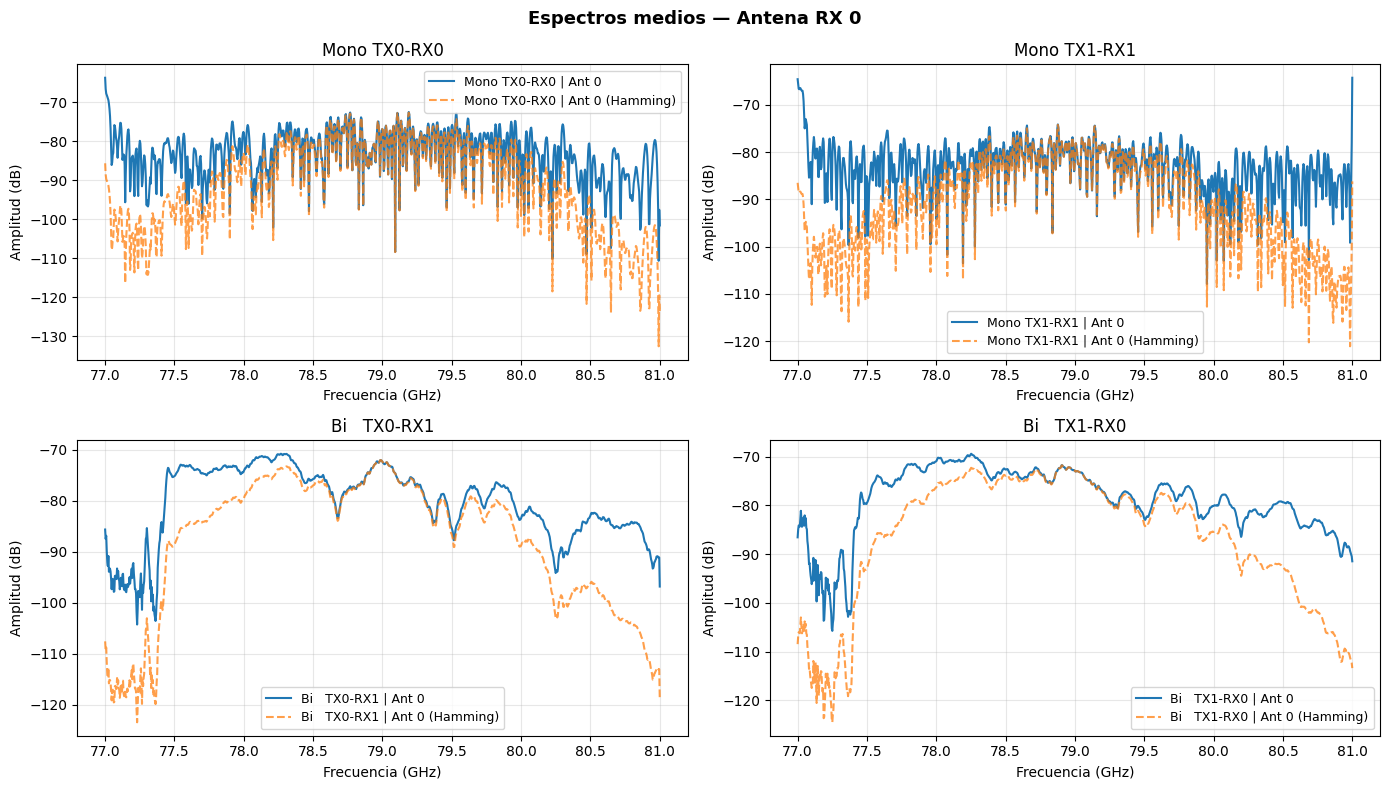

In [3]:
# Vista 2×2: las 4 configuraciones
plot_all_configs_spectrum(data, antenna=0) 

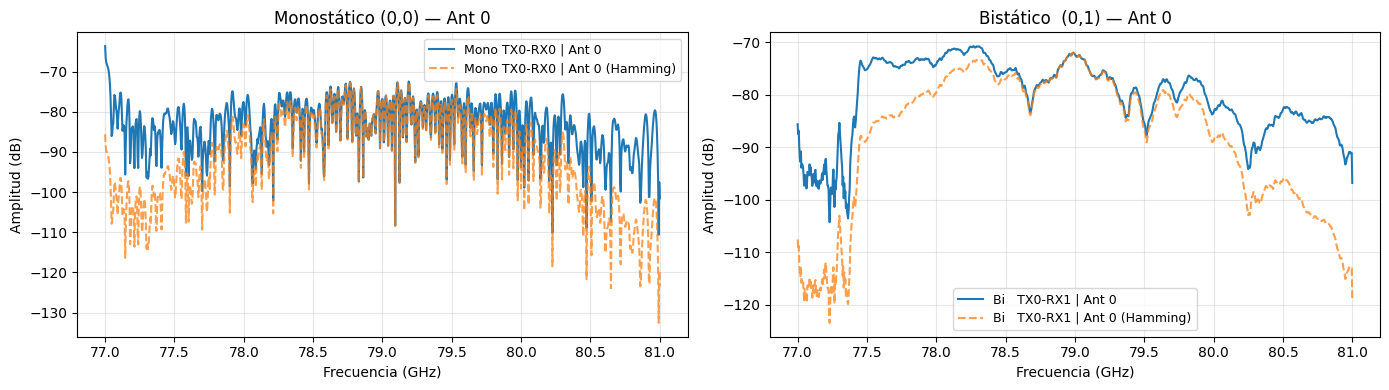

In [4]:
# Comparativa monostático vs bistático en un solo plot (antena 0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_spectrum(data, tx=0, rx=0, antenna=0, title='Monostático (0,0) — Ant 0', ax=axes[0])
plot_spectrum(data, tx=0, rx=1, antenna=0, title='Bistático  (0,1) — Ant 0', ax=axes[1])
plt.tight_layout()
plt.show()

## 3. Range Profile (dominio de distancia)

La **IFFT del espectro de frecuencias** proporciona el Range Profile:
la potencia recibida en función de la distancia al objetivo.
Es la representación física clave para el **Ugly Twin**, ya que codifica
la estructura de multipath del entorno sin geometría explícita.

> Resolución en distancia = c / (2 × BW)

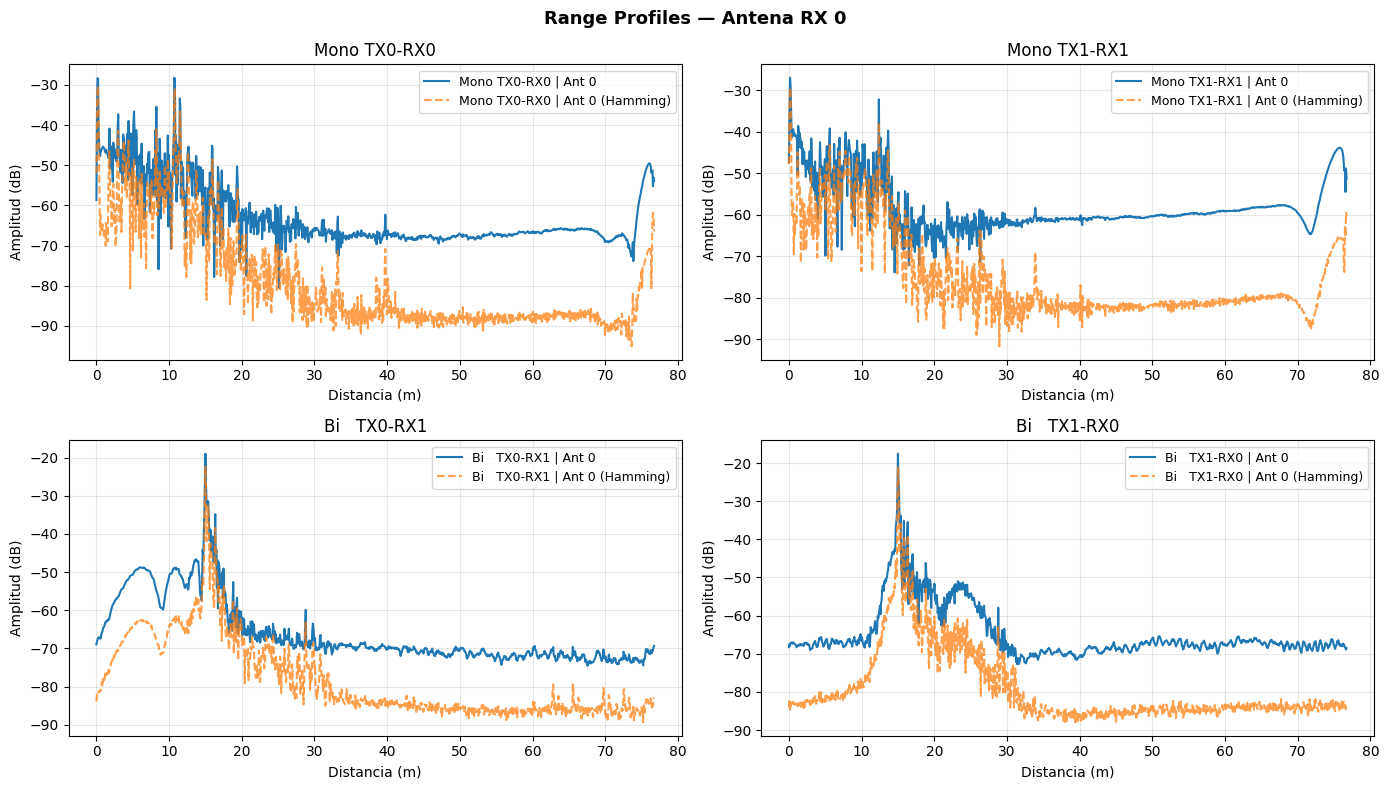

In [5]:
# Vista 2×2: Range Profile de las 4 configuraciones
plot_all_configs_range_profile(data, antenna=0)

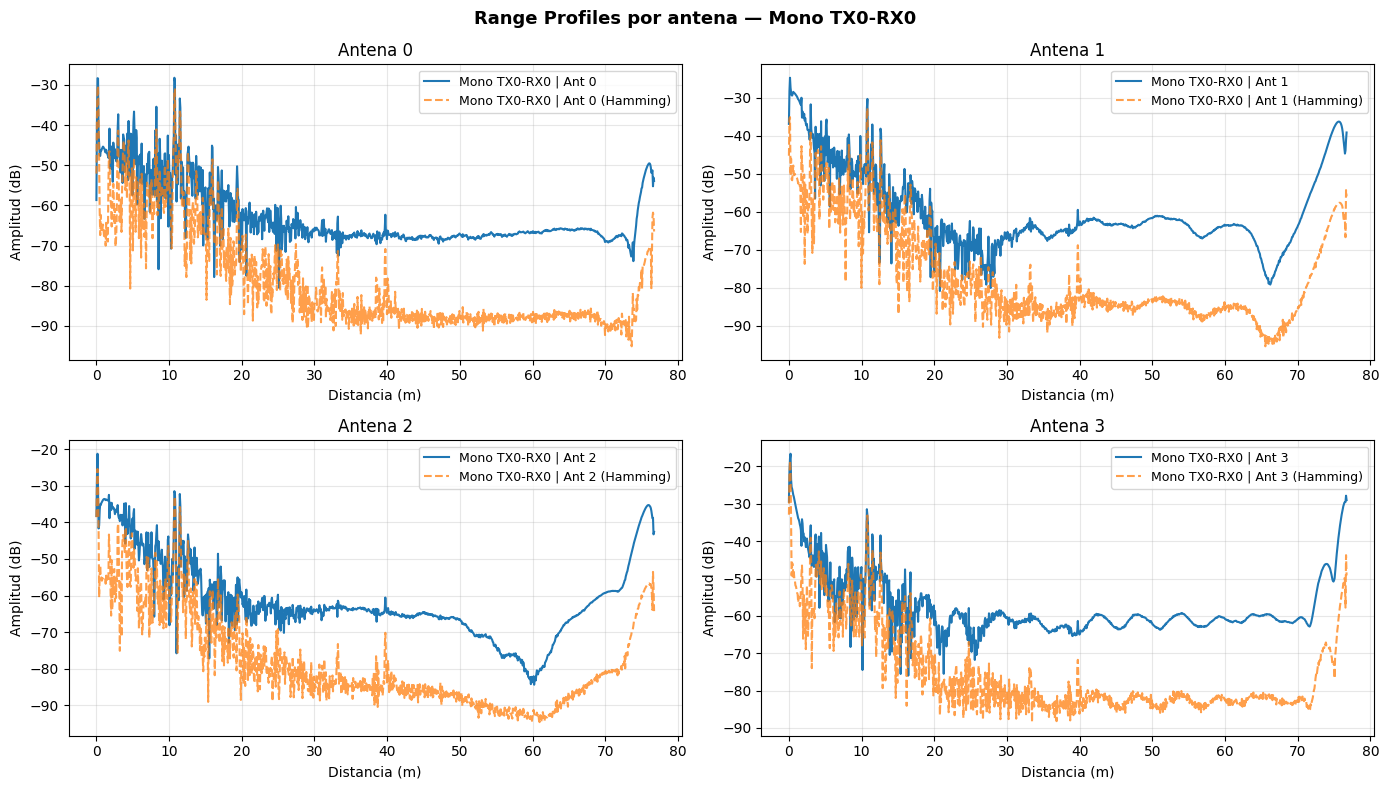

In [6]:
# Comparativa de las 4 antenas receptoras para config monostática (0,0)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Range Profiles por antena — Mono TX0-RX0', fontsize=13, fontweight='bold')
for ant, ax in enumerate(axes.flat):
    plot_range_profile(data, tx=0, rx=0, antenna=ant, title=f'Antena {ant}', ax=ax)
plt.tight_layout()
plt.show()

## 4. Evolución Temporal

Variabilidad del canal a lo largo del tiempo para una frecuencia fija.
Útil para detectar no-estacionariedades o artefactos en la captura.

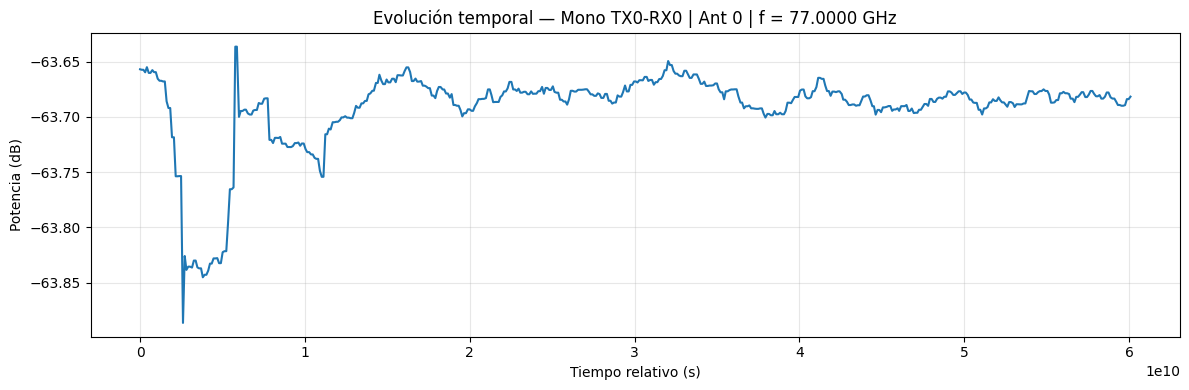

In [7]:
# Monostático (0,0) — antena 0 — frecuencia de máxima potencia media
plot_temporal_evolution(data, tx=0, rx=0, antenna=0)

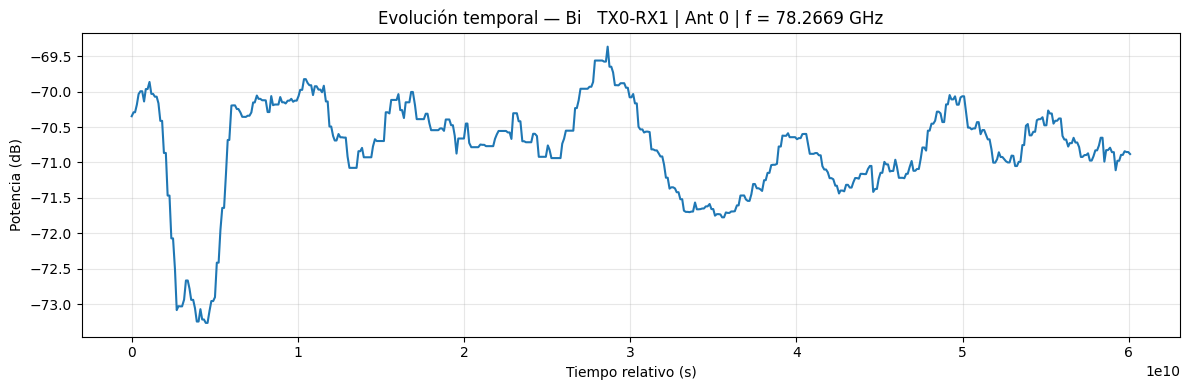

In [8]:
# Bistático (0,1) — antena 0
plot_temporal_evolution(data, tx=0, rx=1, antenna=0)

## 5. Perfil Espacial de Antenas

Heatmap de potencia (dB) para un instante y frecuencia concretos.  
Permite ver si hay antenas con comportamiento anómalo o desequilibrios de ganancia.

frecuencia seleccionada : 79.0020 GHz
instante seleccionado   : idx=274


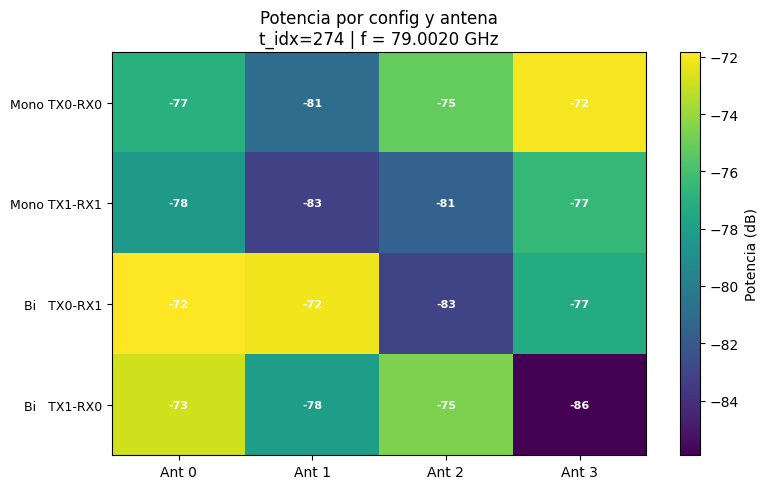

In [9]:
import numpy as np

freq = data['frequency']

# Usar el centro del espectro como ejemplo
freq_idx_mid  = len(freq) // 2
ts_idx_mid    = data['R'].shape[0] // 2

print(f'frecuencia seleccionada : {freq[freq_idx_mid]*1e-9:.4f} GHz')
print(f'instante seleccionado   : idx={ts_idx_mid}')

plot_antenna_matrix(data, freq_idx=freq_idx_mid, timestamp_idx=ts_idx_mid)

## 6. Resumen Estadístico

Tabla con potencia media, variabilidad temporal y dinámica por configuración y antena.

In [10]:
stats = compute_summary_stats(data)
print(stats.to_string(index=False))

      config        tipo  antena  potencia_media_dB  desv_std_temporal_dB  dinamica_dB  freq_pico_GHz
Mono TX0-RX0 Monostático       0             -40.74                  0.14        17.79        77.0000
Mono TX0-RX0 Monostático       1             -39.38                  0.08        20.66        77.0274
Mono TX0-RX0 Monostático       2             -38.90                  0.04        21.35        77.0274
Mono TX0-RX0 Monostático       3             -36.42                  0.02        15.39        77.1251
Mono TX1-RX1 Monostático       0             -40.84                  0.14        17.45        81.0000
Mono TX1-RX1 Monostático       1             -40.93                  0.16        18.83        77.0352
Mono TX1-RX1 Monostático       2             -37.89                  0.03        20.26        77.0352
Mono TX1-RX1 Monostático       3             -37.52                  0.07        20.25        77.0391
Bi   TX0-RX1   Bistático       0             -39.05                  0.61         

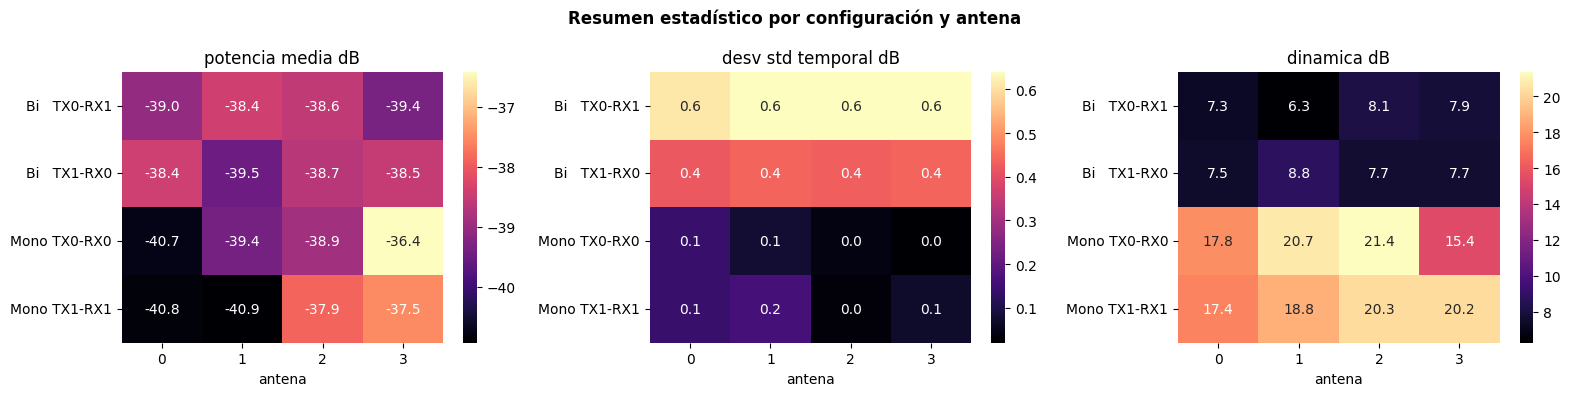

In [11]:
# Heatmap de potencia media por config y antena
pivot = stats.pivot(index='config', columns='antena', values='potencia_media_dB')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['potencia_media_dB', 'desv_std_temporal_dB', 'dinamica_dB']):
    pv = stats.pivot(index='config', columns='antena', values=col)
    sns.heatmap(pv, annot=True, fmt='.1f', cmap='magma', ax=ax, cbar=True)
    ax.set_title(col.replace('_', ' '))
    ax.set_ylabel('')
plt.suptitle('Resumen estadístico por configuración y antena', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Filtrado de banda y guardado de datos procesados

Se filtra el rango de frecuencias activo (≥ 77.6 GHz, como en `00_prueba.ipynb`)
y se guarda el dataset resultante en `data/processed/`.

In [12]:
# Frecuencia de corte: igual que en el notebook de prueba
F_MIN_GHZ = 77.6
F_MAX_GHZ = data['frequency'].max() * 1e-9

data_filtered = select_band(data, f_min_ghz=F_MIN_GHZ, f_max_ghz=F_MAX_GHZ)

freq_f = data_filtered['frequency']
print(f'Frecuencias antes del filtro : {len(data["frequency"])} bins')
print(f'Frecuencias tras el filtro   : {len(freq_f)} bins')
print(f'Rango filtrado               : {freq_f.min()*1e-9:.4f} – {freq_f.max()*1e-9:.4f} GHz')

Frecuencias antes del filtro : 1024 bins
Frecuencias tras el filtro   : 870 bins
Rango filtrado               : 77.6022 – 81.0000 GHz


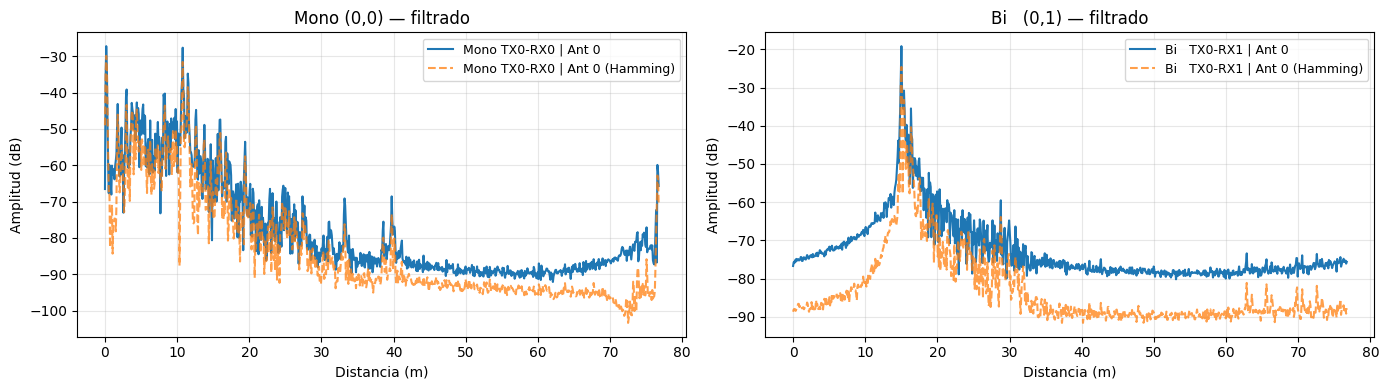

In [13]:
# Verificación rápida: range profile del dataset filtrado
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_range_profile(data_filtered, tx=0, rx=0, antenna=0,
                   title='Mono (0,0) — filtrado', ax=axes[0])
plot_range_profile(data_filtered, tx=0, rx=1, antenna=0,
                   title='Bi   (0,1) — filtrado', ax=axes[1])
plt.tight_layout()
plt.show()

In [14]:
# Guardar versión filtrada en data/processed/
out_path = OUTPUT_DIR / f'data_filtered_{F_MIN_GHZ}ghz.npz'
save_processed(data_filtered, output_path=out_path)

# Guardar versión de potencia y PDP para redes neuronales tradicionales
out_path_power = OUTPUT_DIR / f'data_filtered_{F_MIN_GHZ}ghz_power_pdp.npz'
save_processed_power_pdp(data_filtered, output_path=out_path_power)

✓ Guardado CSI complejo en: C:\Users\carlos\Documents\cosas_carlos\TFG\mi_proyecto_ut\data\processed\data_filtered_77.6ghz.npz  (54.1 MB)


OK Guardado Potencia y PDP en: C:\Users\carlos\Documents\cosas_carlos\TFG\mi_proyecto_ut\data\processed\data_filtered_77.6ghz_power_pdp.npz  (55.9 MB)
